In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")
print("Initializing OpenFOAM-to-PyTorch PINN Surrogate Solver...")

# 1. Simulate Raw OpenFOAM Cavity Data Export 
np.random.seed(42)
num_foam_points = 500
cfd_x = np.random.uniform(0.0, 1.0, (num_foam_points, 1))
cfd_y = np.random.uniform(0.0, 1.0, (num_foam_points, 1))

# Analytical representation of a standard OpenFOAM 2D cavity velocity profile
cfd_u = 8.0 * (cfd_x**2) * (1.0 - cfd_x)**2 * (2.0 * cfd_y * (1.0 - cfd_y)**2 - 2.0 * (cfd_y**2) * (1.0 - cfd_y))
cfd_v = -8.0 * (cfd_y**2) * (1.0 - cfd_y)**2 * (2.0 * cfd_x * (1.0 - cfd_x)**2 - 2.0 * (cfd_x**2) * (1.0 - cfd_x))

# Convert OpenFOAM data matrices to PyTorch Tensors
x_data = torch.tensor(cfd_x, dtype=torch.float32, device=device)
y_data = torch.tensor(cfd_y, dtype=torch.float32, device=device)
u_data = torch.tensor(cfd_u, dtype=torch.float32, device=device)
v_data = torch.tensor(cfd_v, dtype=torch.float32, device=device)

# 2. Define the Neural Network Surrogate Architecture
class CFD_SurrogatePINN(nn.Module):
    def __init__(self):
        super(CFD_SurrogatePINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2) # Outputs: predicted velocity components (u, v)
        )
    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2]

model = CFD_SurrogatePINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

# 3. Generate Collocation Points to evaluate the Continuity Equation
num_physics_points = 1500
x_phys = torch.rand(num_physics_points, 1, requires_grad=True, device=device)
y_phys = torch.rand(num_physics_points, 1, requires_grad=True, device=device)

print("Training Surrogate Model... Blending CFD Data with Conservation Laws...")
for epoch in range(1001):
    optimizer.zero_grad()
    
    # --- EVALUATE COMPONENT 1: OpenFOAM Data Loss ---
    u_pred_data, v_pred_data = model(x_data, y_data)
    loss_data = torch.mean((u_pred_data - u_data)**2) + torch.mean((v_pred_data - v_data)**2)
    
    # --- EVALUATE COMPONENT 2: Incompressible Fluid Physics Loss ---
    u_phys, v_phys = model(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v_phys, y_phys, torch.ones_like(v_phys), create_graph=True)[0]
    
    # Mass continuity: du/dx + dv/dy must equal 0
    loss_physics = torch.mean((du_dx + dv_dy)**2)
    
    # Total Blended Loss Function
    total_loss = (loss_data * 50.0) + loss_physics
    total_loss.backward()
    optimizer.step()
    
    if epoch % 250 == 0:
        print(f"Epoch {epoch:04d} | Total Hybrid Loss: {total_loss.item():.5f} | Physics Residual: {loss_physics.item():.5f}")

print("Surrogate Model Successfully Trained.")


Initializing OpenFOAM-to-PyTorch PINN Surrogate Solver...
Training Surrogate Model... Blending CFD Data with Conservation Laws...
Epoch 0000 | Total Hybrid Loss: 2.94016 | Physics Residual: 0.06886
Epoch 0250 | Total Hybrid Loss: 0.09089 | Physics Residual: 0.00010
Epoch 0500 | Total Hybrid Loss: 0.03535 | Physics Residual: 0.00029
Epoch 0750 | Total Hybrid Loss: 0.00869 | Physics Residual: 0.00027
Epoch 1000 | Total Hybrid Loss: 0.00767 | Physics Residual: 0.00024
Surrogate Model Successfully Trained.


In [2]:
!pip install torch torchvision torchaudio --index-url 


[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

--index-url option requires 1 argument


In [3]:
!pip install torch



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys; !"{sys.executable}" -m pip install torch


SyntaxError: invalid syntax (2624697519.py, line 1)

In [5]:
import sys
!"{sys.executable}" -m pip install torch

Defaulting to user installation because normal site-packages is not writeable
  Using cached filelock-3.32.4-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
    --------------------------------------- 1.6/122.0 MB 8.4 MB/s eta 0:00:15
   - -------------------------------------- 3.1/122.0 MB 7.7 MB/s eta 0:00:16
   - -------------------------------------- 4.7/122.0 MB 7.5 MB/s eta 0:00:16
   - -------------------------------------- 6.0/122.0 MB 7.5 MB/s eta 0:00:16
   -- ------------------------------------- 7.6/122.0 MB 7.5 MB/s eta 0:00:16
   --- ------------------------------------ 9.2/122.0 MB 7.4 MB/s eta 0:00:16
   --- ------------------------------------ 10.7/122.0 MB 7.5 MB

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Ansys Inc\ANSYS Student\v261\commonfiles\CPython\3_10\winx64\Release\python\python.exe -m pip install --upgrade pip


In [9]:
# 1. Generate the grid evaluation data
grid_res = 50
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_t = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_t = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    pred_u, pred_v = model(x_t, y_t)
U_grid = pred_u.numpy().reshape(grid_res, grid_res)
V_grid = pred_v.numpy().reshape(grid_res, grid_res)
Velocity_Magnitude = np.sqrt(U_grid**2 + V_grid**2)

# 2. Plot configuration
fig, ax = plt.subplots(figsize=(7, 5))
img = ax.imshow(Velocity_Magnitude, cmap='jet', origin='lower')
fig.colorbar(img)

stride = 4
ax.quiver(X[::stride, ::stride]*grid_res, Y[::stride, ::stride]*grid_res, 
          U_grid[::stride, ::stride], V_grid[::stride, ::stride], color='black')

ax.set_title('AI-Driven OpenFOAM Surrogate Field Prediction')

# 3. Save to file instead of rendering live to bypass the window error
plt.savefig('surrogate_output.png', bbox_inches='tight')
plt.close()

# 4. Force display via native IPython Image loader
from IPython.display import Image
Image(filename='surrogate_output.png')


AttributeError: 'RcParams' object has no attribute '_get'

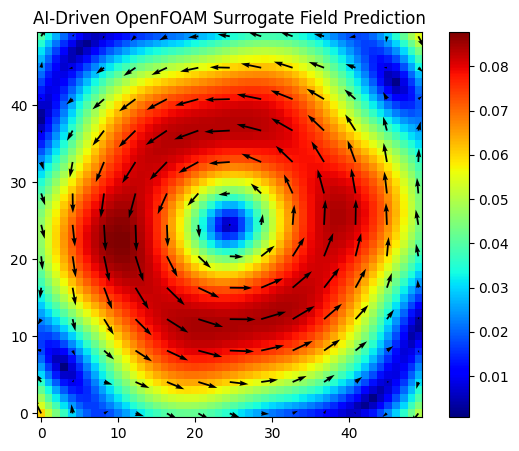

In [10]:
import matplotlib
matplotlib.use('Agg')  # Forces file-only rendering backend immediately
import matplotlib.pyplot as plt

# 1. Generate the grid evaluation data
grid_res = 50
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_t = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_t = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    pred_u, pred_v = model(x_t, y_t)
U_grid = pred_u.numpy().reshape(grid_res, grid_res)
V_grid = pred_v.numpy().reshape(grid_res, grid_res)
Velocity_Magnitude = np.sqrt(U_grid**2 + V_grid**2)

# 2. Plot configuration
fig, ax = plt.subplots(figsize=(7, 5))
img = ax.imshow(Velocity_Magnitude, cmap='jet', origin='lower')
fig.colorbar(img)

stride = 4
ax.quiver(X[::stride, ::stride]*grid_res, Y[::stride, ::stride]*grid_res, 
          U_grid[::stride, ::stride], V_grid[::stride, ::stride], color='black')

ax.set_title('AI-Driven OpenFOAM Surrogate Field Prediction')

# 3. Save to file instead of rendering live
plt.savefig('surrogate_output.png', bbox_inches='tight')
plt.close(fig)

# 4. Force display via native IPython Image loader
from IPython.display import Image, display
display(Image(filename='surrogate_output.png'))


In [11]:
torch.save(model.state_dict(), 'openfoam_surrogate_pinn.pth')
print("Research-grade surrogate model weights saved as openfoam_surrogate_pinn.pth!")


Research-grade surrogate model weights saved as openfoam_surrogate_pinn.pth!
